## Setup

In [1]:
# Set project root to ChessClassification

import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if project_root not in sys.path:
    sys.path.append(project_root)

print(f"Project root added to path: {project_root}")

Project root added to path: /home/zmoraj/ChessClassification


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
from src.network.training import train
from src.network.evaluation import evaluate, analyze_model_performance
from src.preprocessing.dataset import ChessBoardDataset
from src.utils.dataset_utils import calculate_stats, build_transforms
from src.utils.plotting import visualize_test_samples, plot_training_history, plot_feature_maps
from src.constants import CLASS_MAP

In [3]:
# Load data 

TRAIN_DATA_ROOT = os.path.join(project_root, "data/train/synthetic")
VAL_DATA_ROOT = os.path.join(project_root, "data/validation/synthetic")
TEST_SYNTHETIC_DATA_ROOT = os.path.join(project_root, "data/test/synthetic") 
TEST_REAL_DATA_ROOT = os.path.join(project_root, "data/test/real")
BATCH_SIZE = 2
NUM_WORKERS = 4
SIZE = 112

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

# Compute statistics
train_mean, train_std, test_mean, test_std = calculate_stats(TRAIN_DATA_ROOT, TEST_REAL_DATA_ROOT, SIZE, SIZE, NUM_WORKERS)

# Build final datasets and DataLoaders
baseline_config = {} 
train_transform = build_transforms(train_mean, train_std, config=baseline_config)
test_transform = build_transforms(test_mean, test_std, config=baseline_config)

train_dataset = ChessBoardDataset(root_dir=TRAIN_DATA_ROOT, transform=train_transform)
val_dataset = ChessBoardDataset(root_dir=VAL_DATA_ROOT, transform=train_transform)
test_synthetic_dataset = ChessBoardDataset(root_dir=TEST_SYNTHETIC_DATA_ROOT, transform=train_transform)
test_real_dataset = ChessBoardDataset(root_dir=TEST_REAL_DATA_ROOT, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_synthetic_loader = DataLoader(test_synthetic_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_real_loader = DataLoader(test_real_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

device: cuda
Training samples: 1800 | Test samples: 205
Computing mean and std for training data...


Calculating Stats: 100%|██████████| 113/113 [00:32<00:00,  3.53it/s]



Calculated training mean: [0.7266303300857544, 0.6799918413162231, 0.5675383806228638]
Calculated training std:  [0.08976191282272339, 0.09742976725101471, 0.08831595629453659]

Computing mean and std for test data...


Calculating Stats: 100%|██████████| 13/13 [00:04<00:00,  3.23it/s]


Calculated test mean: [0.7061654329299927, 0.6712028980255127, 0.5853357911109924]
Calculated test std:  [0.13416209816932678, 0.14039230346679688, 0.1279790848493576]



In [4]:
# Define baseline model

def get_baseline_model(num_classes=13):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    
    # Replace final FC layer
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    
    return model

In [5]:
# Initialize model

model = get_baseline_model().to(device)

print("\nModel Initialized: ResNet18 (Pretrained)")
print(f"Output classes: {model.fc.out_features}")


Model Initialized: ResNet18 (Pretrained)
Output classes: 13


## Training

Training on cuda for 5 epochs...


Training Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5 | Train: Loss=0.0480 Acc=0.9871  Val: Loss=0.0032 Acc=0.9991   [Saved Best]
Epoch 2/5 | Train: Loss=0.0045 Acc=0.9992  Val: Loss=0.0130 Acc=0.9959  
Epoch 3/5 | Train: Loss=0.0043 Acc=0.9992  Val: Loss=0.0018 Acc=0.9994   [Saved Best]
Epoch 4/5 | Train: Loss=0.0034 Acc=0.9995  Val: Loss=0.0010 Acc=0.9998   [Saved Best]
Epoch 5/5 | Train: Loss=0.0021 Acc=0.9997  Val: Loss=0.0003 Acc=1.0000   [Saved Best]

Training complete in 3m 40s
Best Val Acc: 1.0000


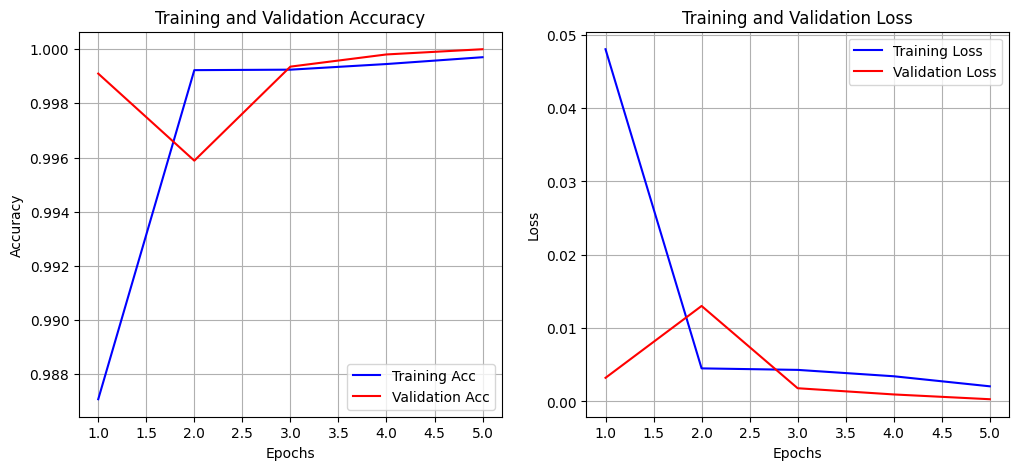

In [6]:
# Training loop

# Configuration
lr = 1e-4
num_epochs = 5
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# Training
best_model, history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=None,
    num_epochs=num_epochs,
    device=device,
    save_path=os.path.join(project_root, 'models/baseline_new_data.pth')
)

# Plotting train and validation statistics
plot_training_history(history)

## Evaluation

In [7]:
# Evaluation on synthetic test data

test_synthetic_dataset.return_fen = False
square_acc, board_acc = evaluate(best_model, test_synthetic_loader, device)

print(f"Square accuracy: {square_acc:.2f}")
print(f"Board accuracy: {board_acc:.2f}")

Starting Evaluation on 402 boards...


Evaluating:   0%|          | 0/201 [00:00<?, ?it/s]

Square accuracy: 99.97
Board accuracy: 98.51


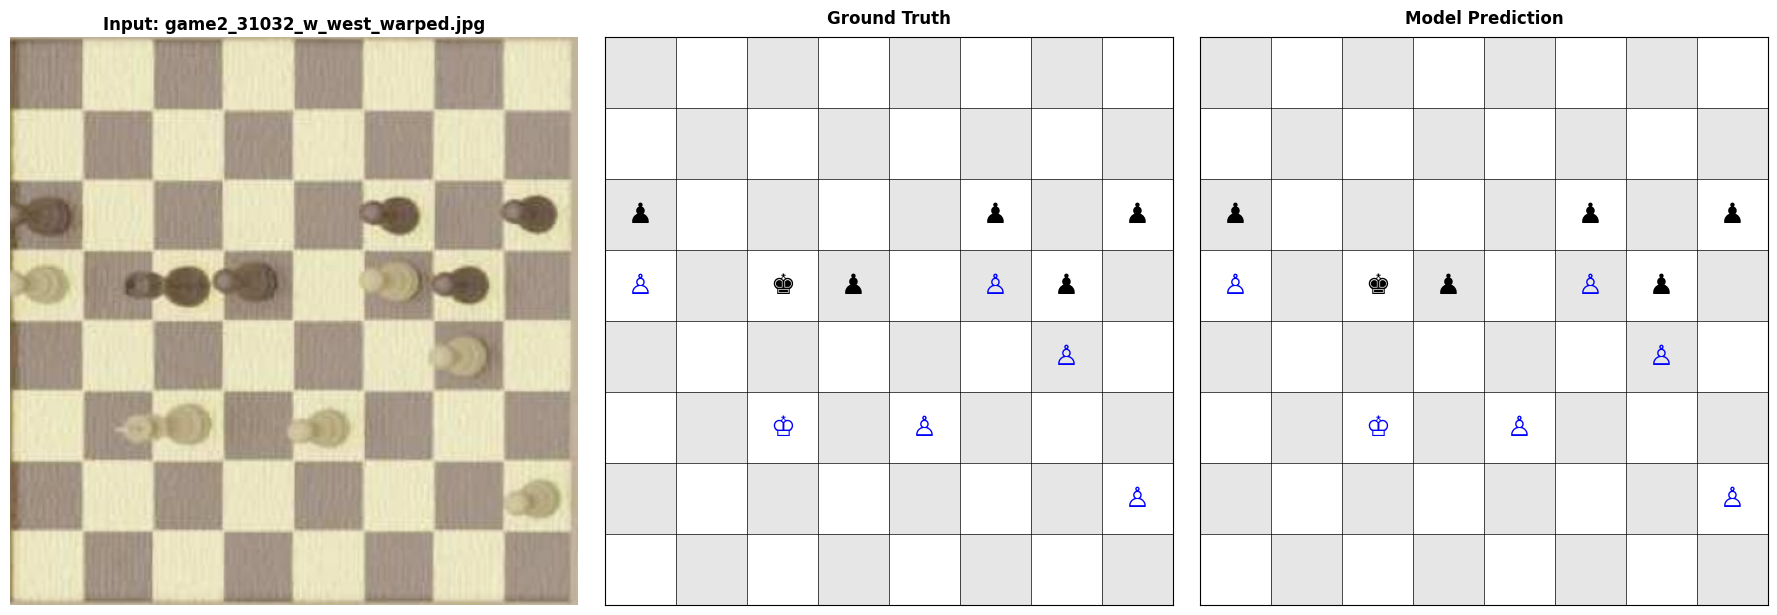

True FEN: 8/8/p4p1p/P1kp1Pp1/6P1/2K1P3/7P/8
Pred FEN: 8/8/p4p1p/P1kp1Pp1/6P1/2K1P3/7P/8
PERFECT MATCH


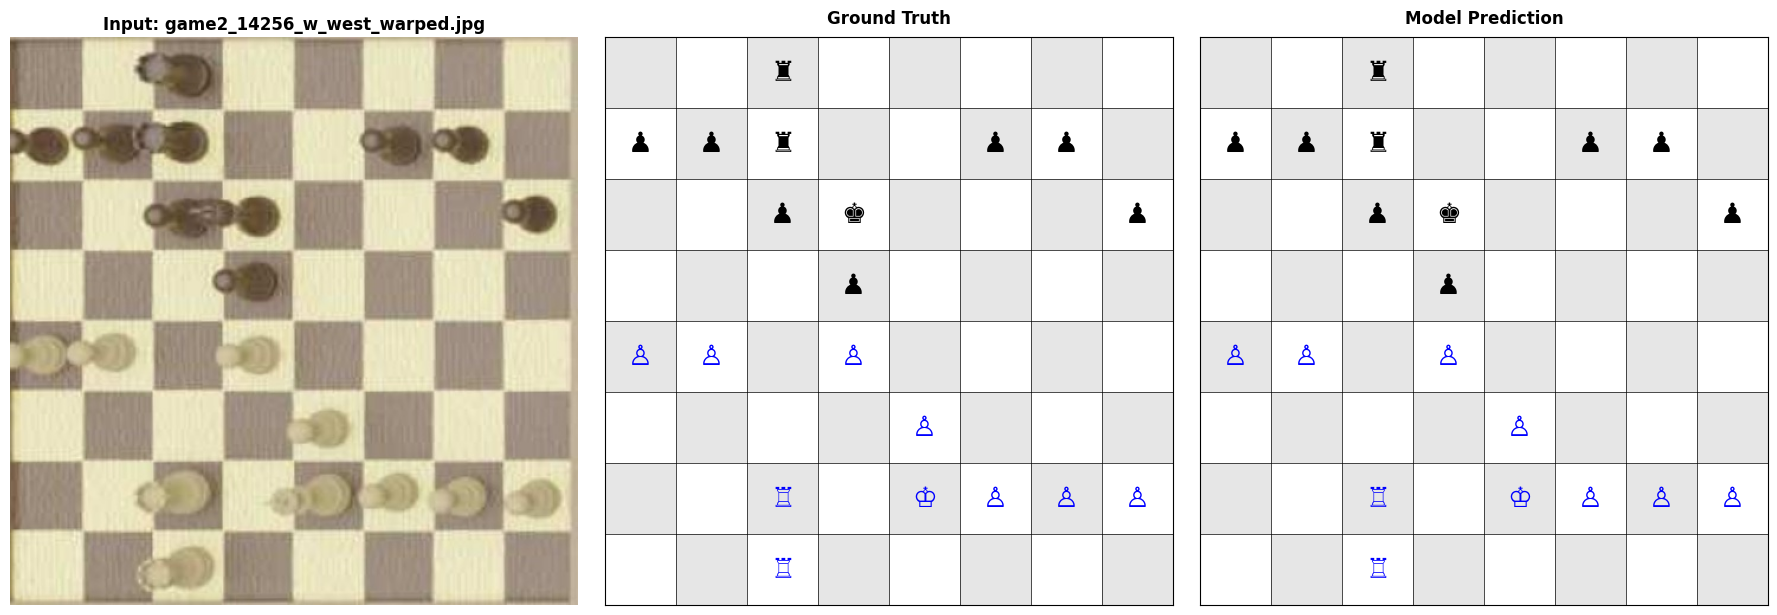

True FEN: 2r5/ppr2pp1/2pk3p/3p4/PP1P4/4P3/2R1KPPP/2R5
Pred FEN: 2r5/ppr2pp1/2pk3p/3p4/PP1P4/4P3/2R1KPPP/2R5
PERFECT MATCH


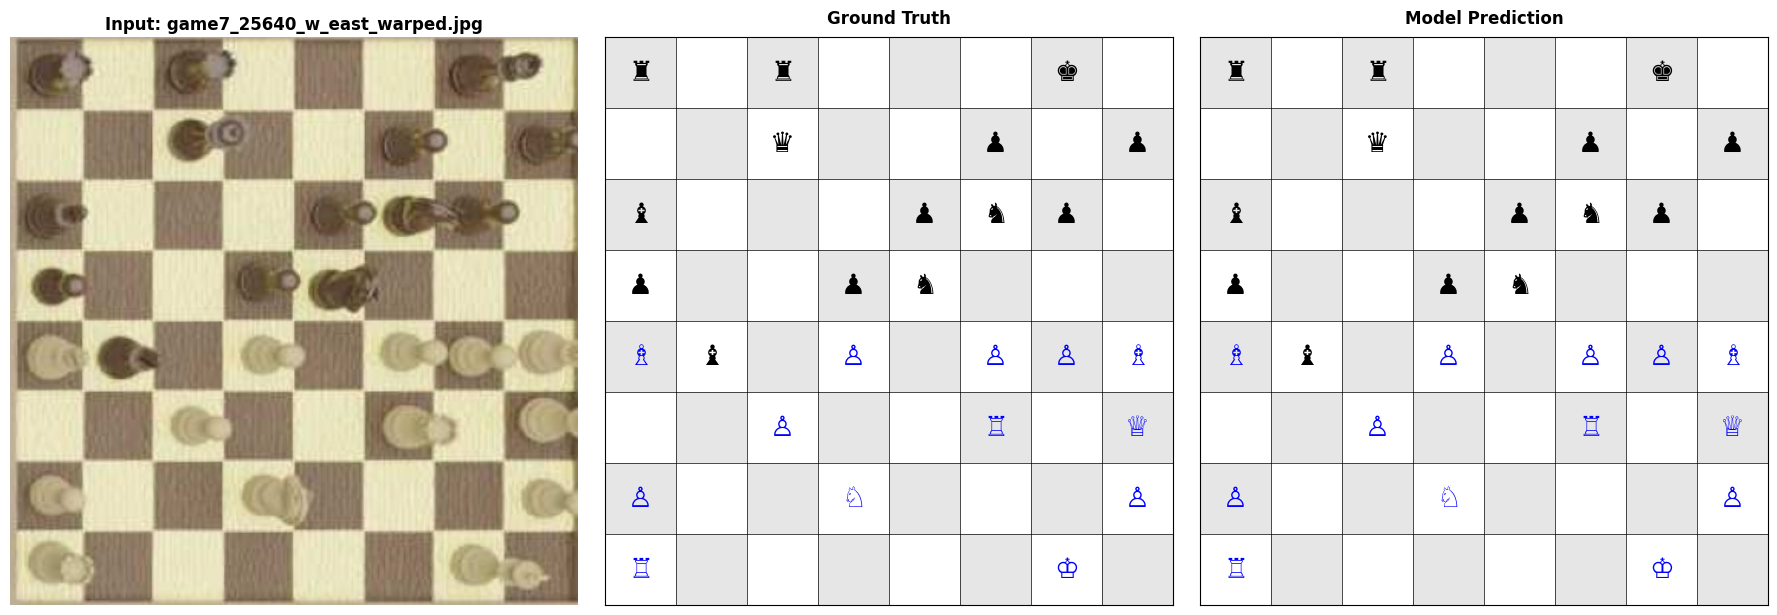

True FEN: r1r3k1/2q2p1p/b3pnp1/p2pn3/Bb1P1PPB/2P2R1Q/P2N3P/R5K1
Pred FEN: r1r3k1/2q2p1p/b3pnp1/p2pn3/Bb1P1PPB/2P2R1Q/P2N3P/R5K1
PERFECT MATCH


In [8]:
# Visualizing model outputs

test_synthetic_dataset.return_fen = True
visualize_test_samples(model, test_synthetic_dataset, num_samples=3, device=device)

In [9]:
# Evaluation on real test data

test_real_dataset.return_fen = False
square_acc, board_acc = evaluate(best_model, test_real_loader, device)

print(f"Square accuracy: {square_acc:.2f}")
print(f"Board accuracy: {board_acc:.2f}")

Starting Evaluation on 205 boards...


Evaluating:   0%|          | 0/103 [00:00<?, ?it/s]

Square accuracy: 72.10
Board accuracy: 0.00


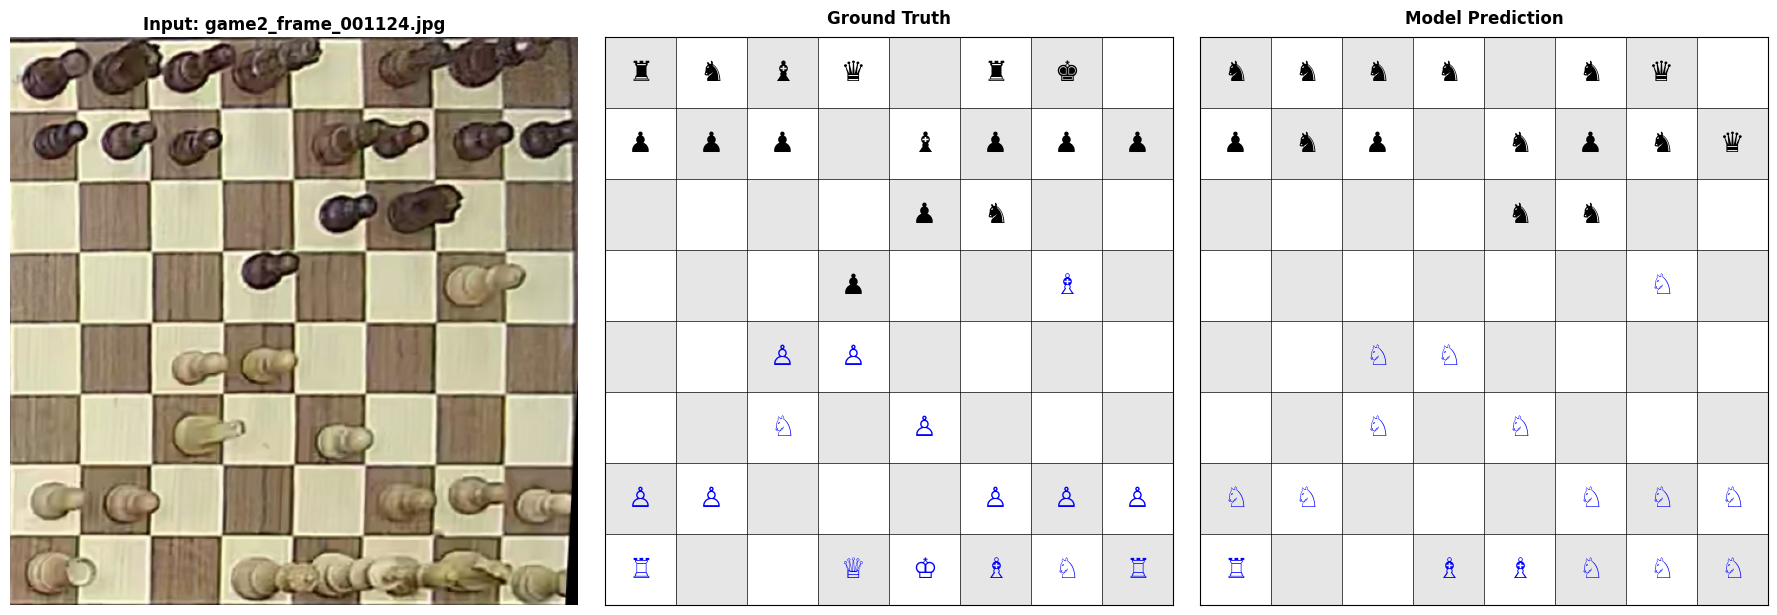

True FEN: rnbq1rk1/ppp1bppp/4pn2/3p2B1/2PP4/2N1P3/PP3PPP/R2QKBNR
Pred FEN: nnnn1nq1/pnp1npnq/4nn2/6N1/2NN4/2N1N3/NN3NNN/R2BBNNN
MISMATCH



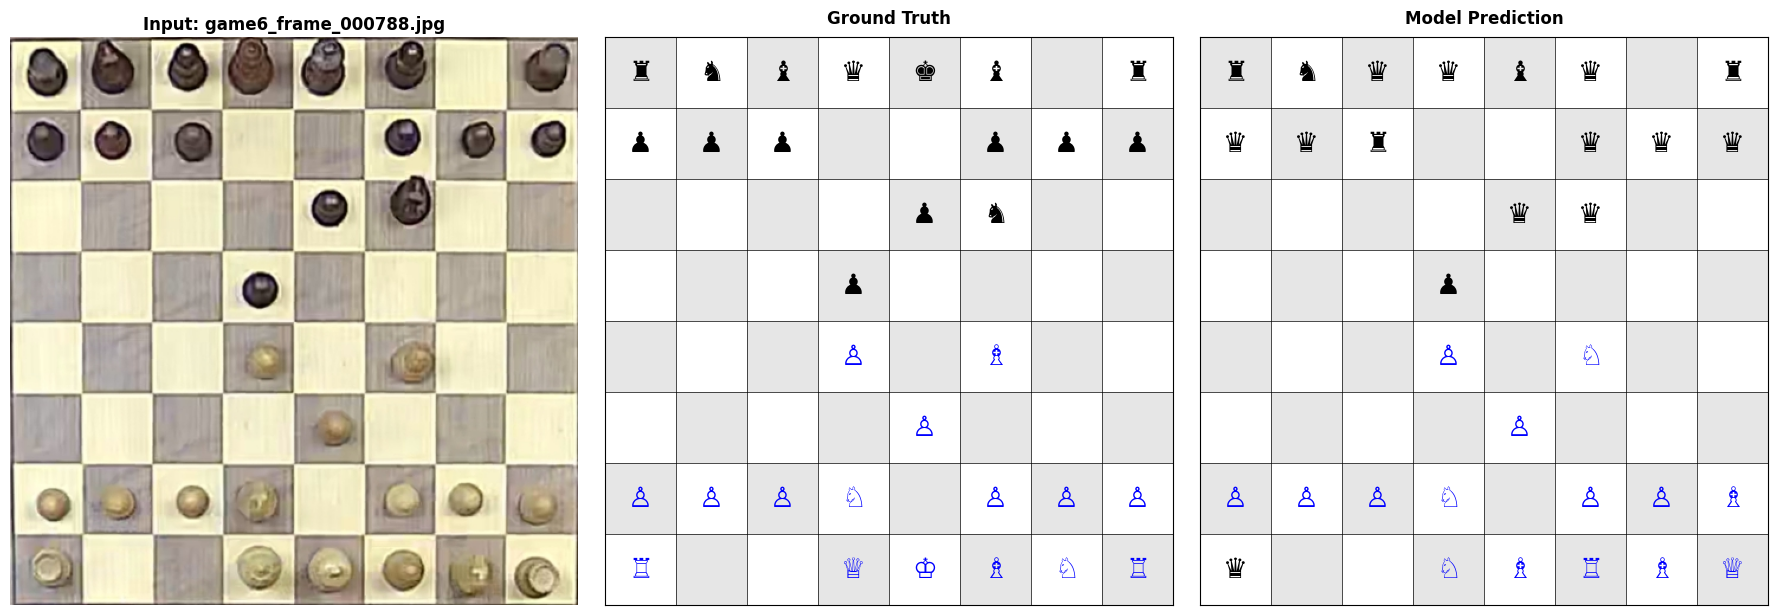

True FEN: rnbqkb1r/ppp2ppp/4pn2/3p4/3P1B2/4P3/PPPN1PPP/R2QKBNR
Pred FEN: rnqqbq1r/qqr2qqq/4qq2/3p4/3P1N2/4P3/PPPN1PPB/q2NBRBQ
MISMATCH



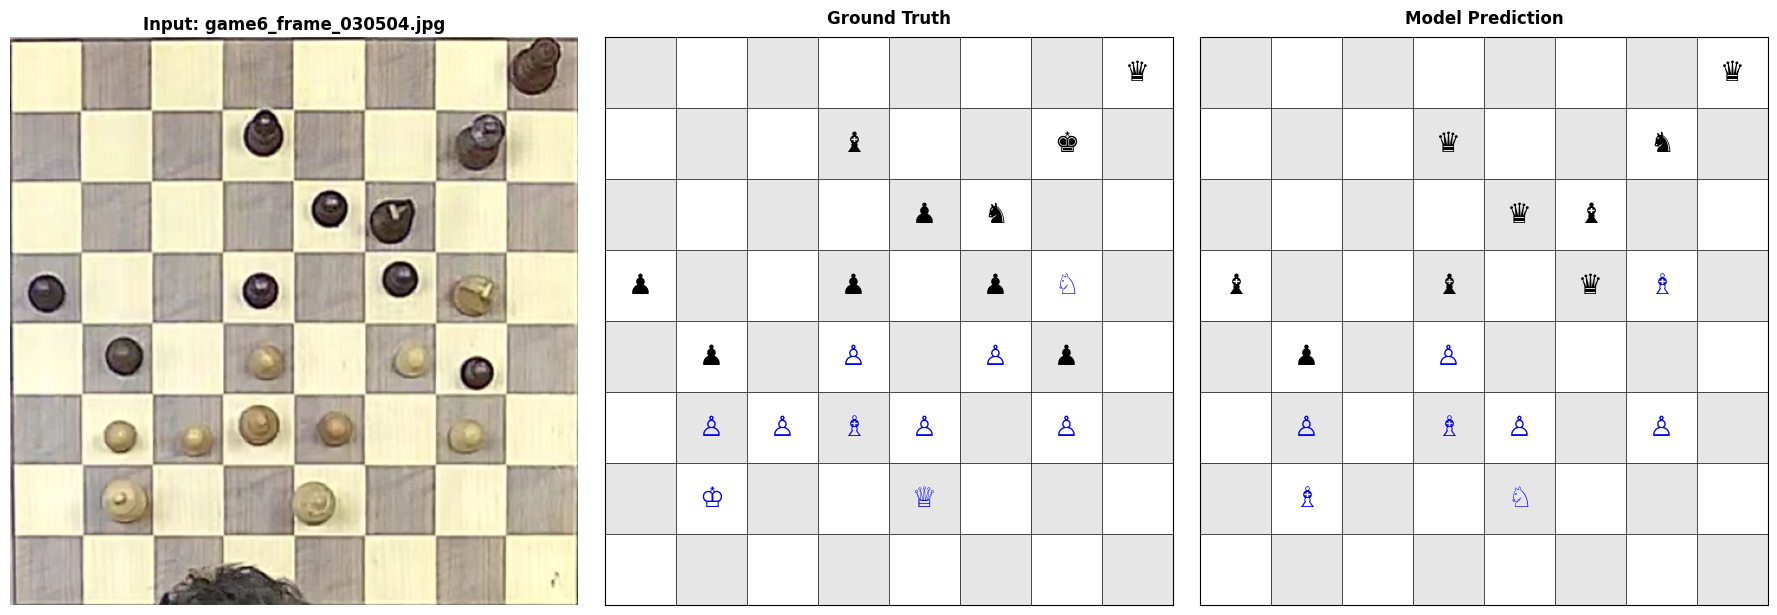

True FEN: 7q/3b2k1/4pn2/p2p1pN1/1p1P1Pp1/1PPBP1P1/1K2Q3/8
Pred FEN: 7q/3q2n1/4qb2/b2b1qB1/1p1P4/1P1BP1P1/1B2N3/8
MISMATCH



In [10]:
# Visualizing model outputs

test_real_dataset.return_fen = True
visualize_test_samples(best_model, test_real_dataset, num_samples=3, device=device)

Accuracy per Class:

white_pawn: 27.79% (393/1414 correct)
white_rook: 21.30% (59/277 correct)
white_knight: 73.45% (166/226 correct)
white_bishop: 40.23% (103/256 correct)
white_queen: 1.75% (3/171 correct)
white_king: 0.00% (0/205 correct)
black_pawn: 31.17% (437/1402 correct)
black_rook: 32.88% (97/295 correct)
black_knight: 54.59% (125/229 correct)
black_bishop: 4.86% (12/247 correct)
black_queen: 21.76% (37/170 correct)
black_king: 4.39% (9/205 correct)
empty     : 99.94% (8018/8023 correct)




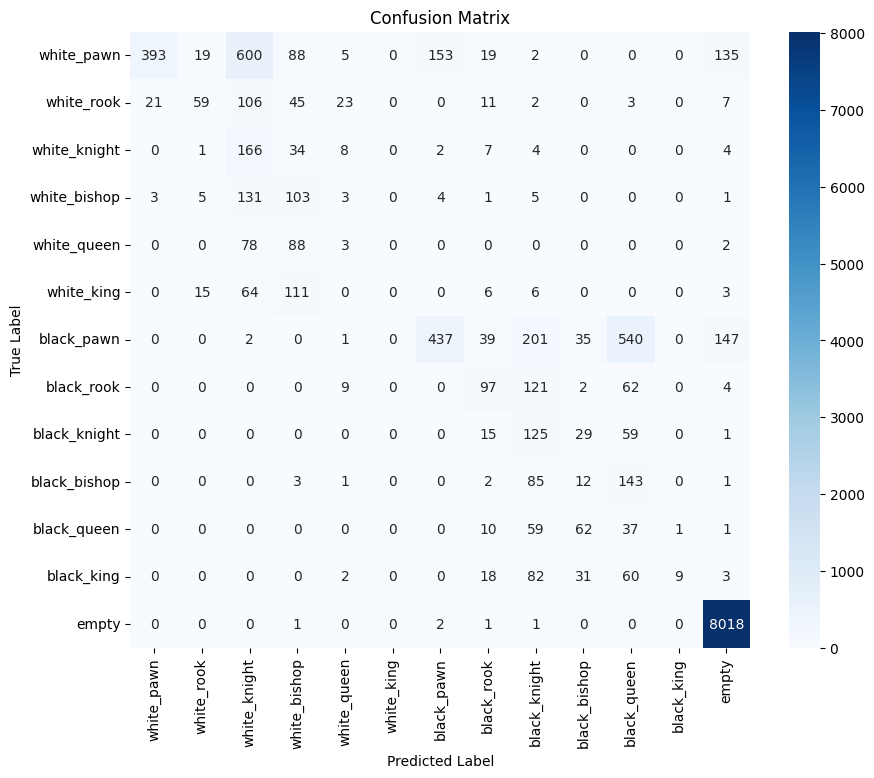

In [11]:
# Analyzing model outputs and performance

class_names = list(CLASS_MAP.keys())
test_real_dataset.return_fen = False
analyze_model_performance(best_model, test_real_loader, class_names, device)

In [12]:
def collect_images(dataset, class_names, classes_to_plot):
    collected_images = []
    labels_for_plot = []
    
    print("Collecting samples...")
    for cls_name in classes_to_plot:
        count = 0
    
        for i in range(len(dataset)):
            if count >= samples_per_class: 
                break
            
            imgs, lbls = dataset[i]
            
            target_idx = class_names.index(cls_name)
            matches = (lbls == target_idx).nonzero(as_tuple=True)[0]
            
            for idx in matches:
                if count >= samples_per_class: 
                    break
                collected_images.append(imgs[idx])
                labels_for_plot.append(cls_name)
                count += 1

    return collected_images, labels_for_plot


test_synthetic_dataset.return_fen = False
classes_to_plot = class_names
samples_per_class = 5 

## Real image feature maps

Extracting features and running PCA...



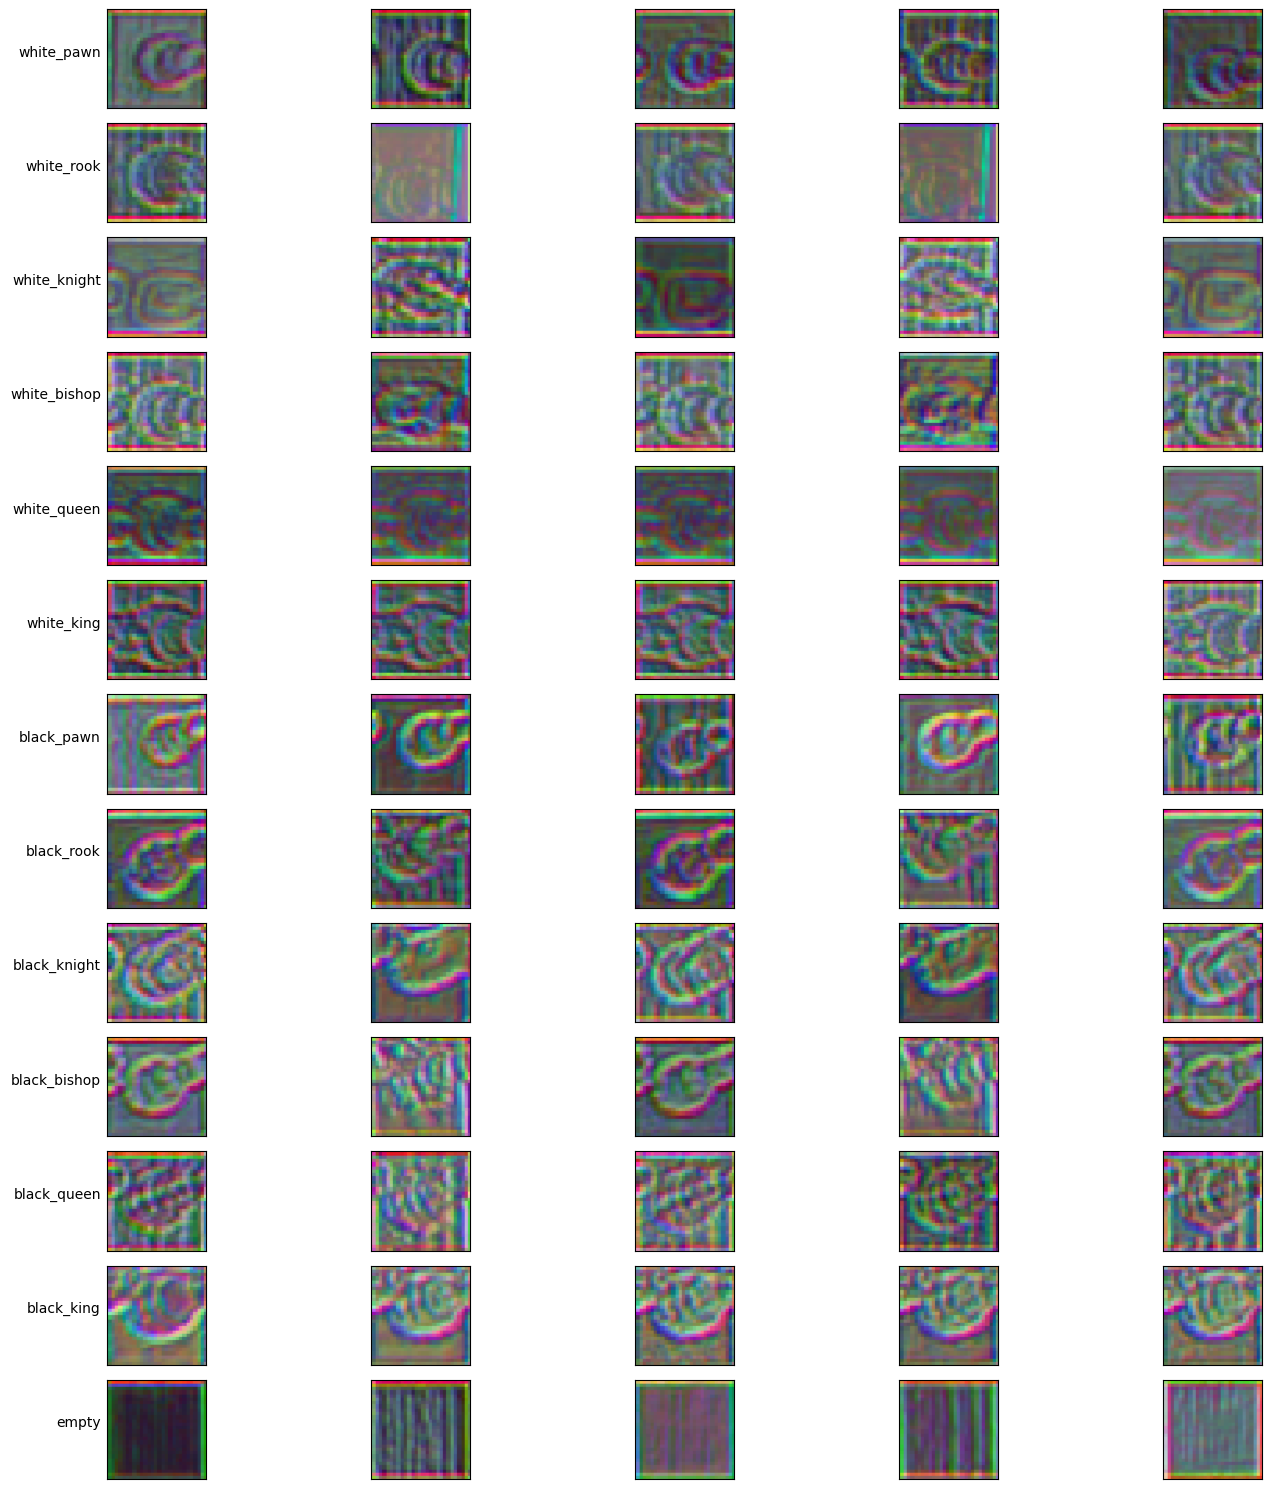

In [13]:
collected_images, labels_for_plot = collect_images(test_real_dataset, class_names, classes_to_plot)
plot_feature_maps(best_model, collected_images, classes_to_plot, labels_for_plot, samples_per_class)

## Synthetic image feature maps

Extracting features and running PCA...



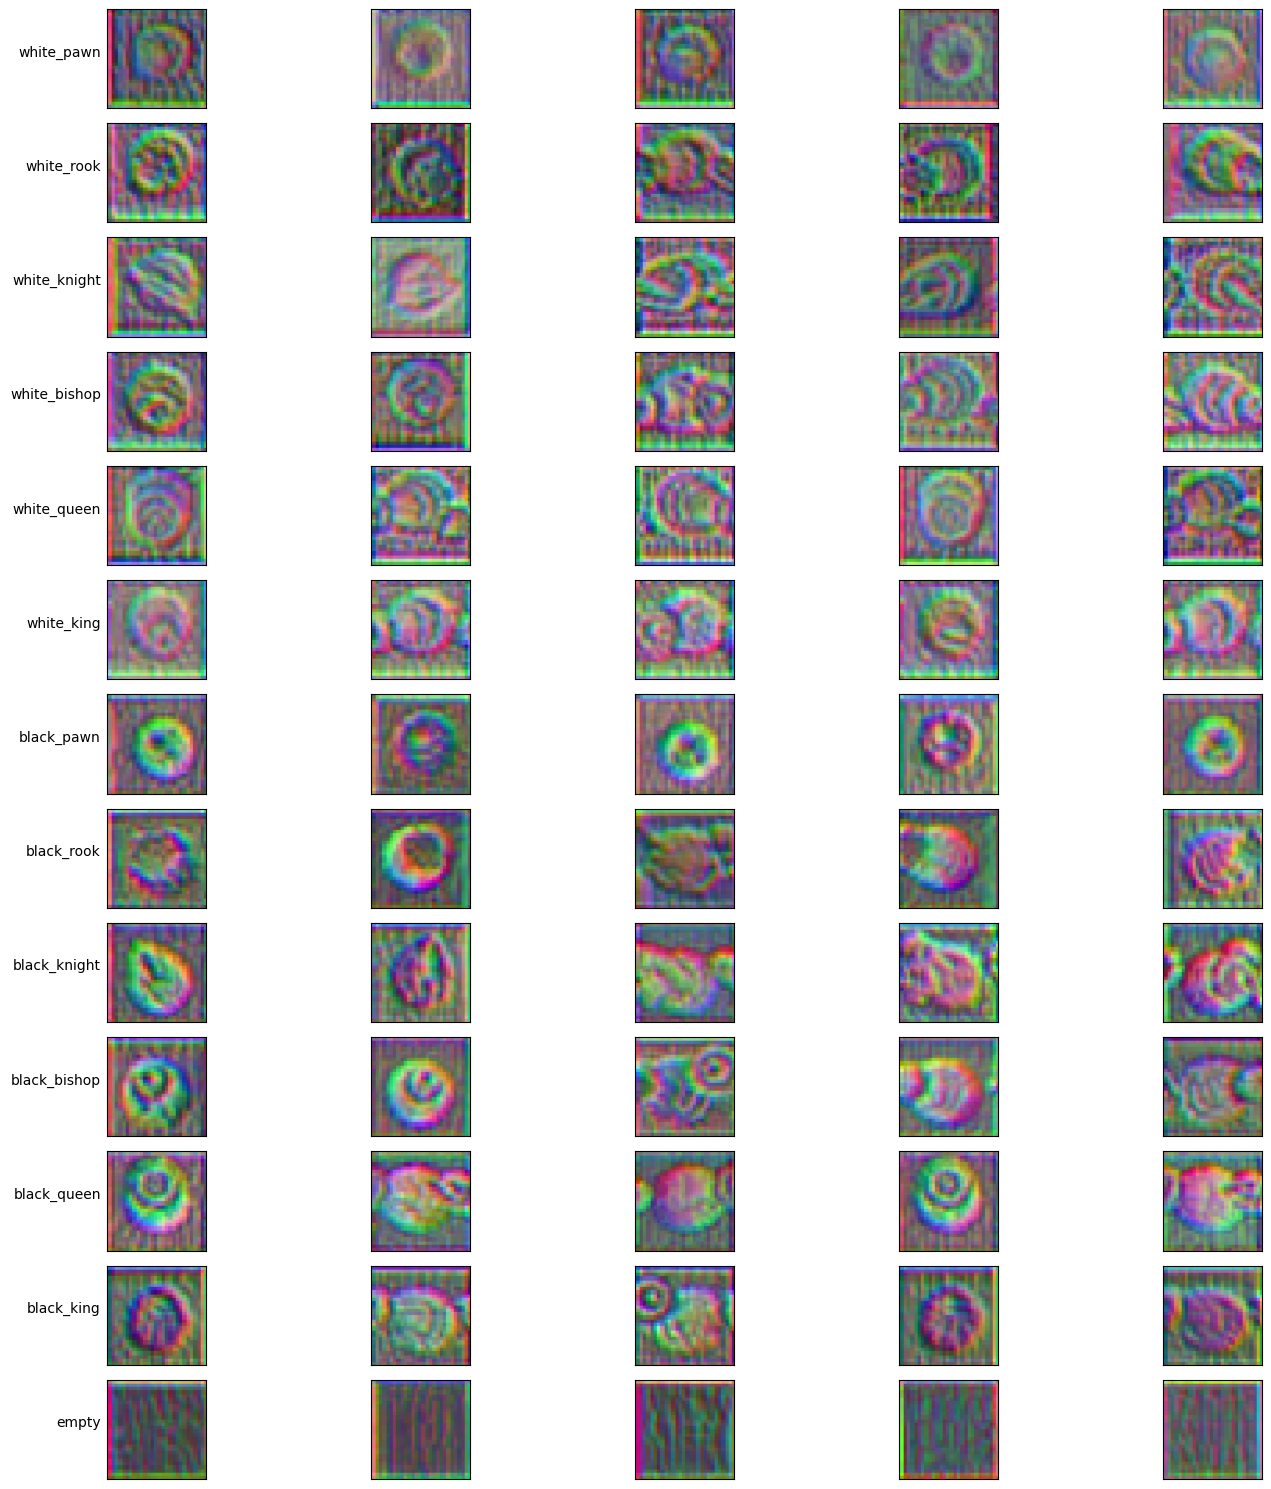

In [14]:
collected_images, labels_for_plot = collect_images(test_synthetic_dataset, class_names, classes_to_plot)
plot_feature_maps(best_model, collected_images, classes_to_plot, labels_for_plot, samples_per_class)